### Import Required Libraries

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
fake = pd.read_csv(r"C:\Users\Dell\Downloads\archive (2)\Fake.csv")
true = pd.read_csv(r"C:\Users\Dell\Downloads\archive (2)\True.csv")

fake["label"] = 0   # Fake
true["label"] = 1   # Real

df = pd.concat([fake, true], ignore_index=True)
print(df.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  


In [ ]:
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


### Exploratory Data Analysis

In [ ]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [ ]:
fake["label"] = 0
true["label"] = 1

In [ ]:
df.duplicated().sum()

np.int64(209)

In [ ]:
print(df.head())
print(df.shape)

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  
(44689, 5)


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 44689 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44689 non-null  str  
 1   text     44689 non-null  str  
 2   subject  44689 non-null  str  
 3   date     44689 non-null  str  
 4   label    44689 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.0 MB


In [ ]:
df["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

In [ ]:
df["content"] = df["title"] + " " + df["subject"] + " " + df["text"]

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

In [ ]:
df["content"] = df["content"].apply(clean_text)

In [ ]:
X = df["content"]

y = df["label"]

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X)

In [ ]:
X = tokenizer.texts_to_sequences(X)

In [ ]:
X = pad_sequences(X, maxlen=500)

### Data Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

### Model Creation

In [ ]:
model = Sequential()

model.add(Embedding(input_dim=5000,
                    output_dim=128,
                    input_length=500))

model.add(LSTM(128))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
history = model.fit(

    X_train,

    y_train,

    epochs=5,

    batch_size=64,

    validation_data=(X_test, y_test)
)

Epoch 1/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 612s 1s/step - accuracy: 0.9226 - loss: 0.2192 - val_accuracy: 0.9579 - val_loss: 0.1300
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 416s 744ms/step - accuracy: 0.9543 - loss: 0.1315 - val_accuracy: 0.9352 - val_loss: 0.1593
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 883s 2s/step - accuracy: 0.9764 - loss: 0.0740 - val_accuracy: 0.9731 - val_loss: 0.0800
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 493s 882ms/step - accuracy: 0.9862 - loss: 0.0454 - val_accuracy: 0.9890 - val_loss: 0.0327
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 472s 844ms/step - accuracy: 0.9944 - loss: 0.0199 - val_accuracy: 0.9928 - val_loss: 0.0215


In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

280/280 ━━━━━━━━━━━━━━━━━━━━ 48s 169ms/step


In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.9928395614231371


In [ ]:
print(confusion_matrix(y_test, y_pred))

[[4700   38]
 [  26 4174]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4738
           1       0.99      0.99      0.99      4200

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



### FakeNews Prediction

In [ ]:
news = ["The government announced a new education policy today."]

news = [clean_text(i) for i in news]

news = tokenizer.texts_to_sequences(news)

news = pad_sequences(news, maxlen=500)

prediction = model.predict(news)

if prediction > 0.5:
    print("Real News")
else:
    print("Fake News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Fake News


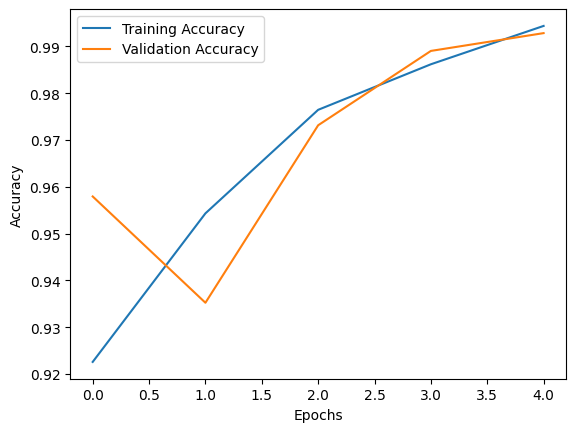

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()